# 05 · Eksperimen Skenario: Kapan Federated Learning Menolong?

Kita jalankan semua metode pada setiap skenario, lalu pada beberapa tingkat heterogenitas.
Hasil di-cache ke `results/`, jadi eksekusi kedua berjalan cepat.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.data import SCENARIOS, get_scenario
from fedprob.experiment import run_experiment_cached, METHOD_LABELS
from fedprob.plots import plot_fan

MAIN = ["ets", "local", "fedavg", "fedprox", "fedavg_ft", "central", "oracle"]
results = {s: run_experiment_cached(s, cache_dir="../results", verbose=False) for s in SCENARIOS}

## Ringkasan CRPS (rata-rata semua bank, lebih kecil lebih baik)

In [3]:
crps = pd.DataFrame({s: r.summary()["CRPS"] for s, r in results.items()}).loc[MAIN]
# Sorot metode realistis terbaik (tanpa Oracle & Centralized, yang tidak bisa dicapai di dunia nyata)
realistic = [METHOD_LABELS[m] for m in MAIN if m not in ("oracle", "central")]
crps.rename(index=METHOD_LABELS).style.format("{:.3f}").highlight_min(axis=0, subset=pd.IndexSlice[realistic, :], color="#cde7cd")

,normal,heterogen,data_langka,shock,bank_baru
method,,,,,
ETS (Holt-Winters),0.203,0.209,0.197,0.442,0.201
Local-only (tiap bank sendiri),0.195,0.201,0.210,0.510,0.193
Federated (FedAvg),0.203,0.223,0.194,0.504,0.195
Federated (FedProx),0.198,0.223,0.202,0.507,0.200
FedAvg + fine-tune lokal,0.201,0.205,0.192,0.509,0.194
Centralized (data digabung),0.199,0.212,0.195,0.470,0.204
Oracle (distribusi sebenarnya),0.162,0.173,0.157,0.185,0.160


## Coverage interval 80% (ideal ≈ 0.80)

In [4]:
cov = pd.DataFrame({s: r.summary()["Coverage80"] for s, r in results.items()}).loc[MAIN]
cov.rename(index=METHOD_LABELS).style.format("{:.0%}")

,normal,heterogen,data_langka,shock,bank_baru
method,,,,,
ETS (Holt-Winters),82%,81%,81%,68%,82%
Local-only (tiap bank sendiri),70%,71%,80%,41%,73%
Federated (FedAvg),68%,72%,73%,40%,72%
Federated (FedProx),66%,69%,67%,40%,66%
FedAvg + fine-tune lokal,66%,70%,72%,39%,71%
Centralized (data digabung),67%,71%,72%,43%,67%
Oracle (distribusi sebenarnya),72%,72%,72%,74%,72%


## Fokus: bank kecil pada skenario `data_langka`
Pertanyaan kunci: apakah bank dengan data sedikit paling diuntungkan oleh federasi?

In [5]:
m = results["data_langka"].metrics
m[m.method.isin(["local", "fedavg", "fedavg_ft", "central"])].pivot(index="bank", columns="method", values="CRPS")[["local", "fedavg", "fedavg_ft", "central"]]

method,local,fedavg,fedavg_ft,central
bank,,,,
Bank A,0.217,0.204,0.204,0.214
Bank B,0.143,0.151,0.144,0.147
Bank C,0.198,0.206,0.207,0.211
Bank D,0.221,0.220,0.226,0.217
Bank E,0.231,0.236,0.227,0.238
Bank F,0.238,0.167,0.167,0.171
Bank G,0.235,0.184,0.184,0.181
Bank H,0.194,0.188,0.177,0.178


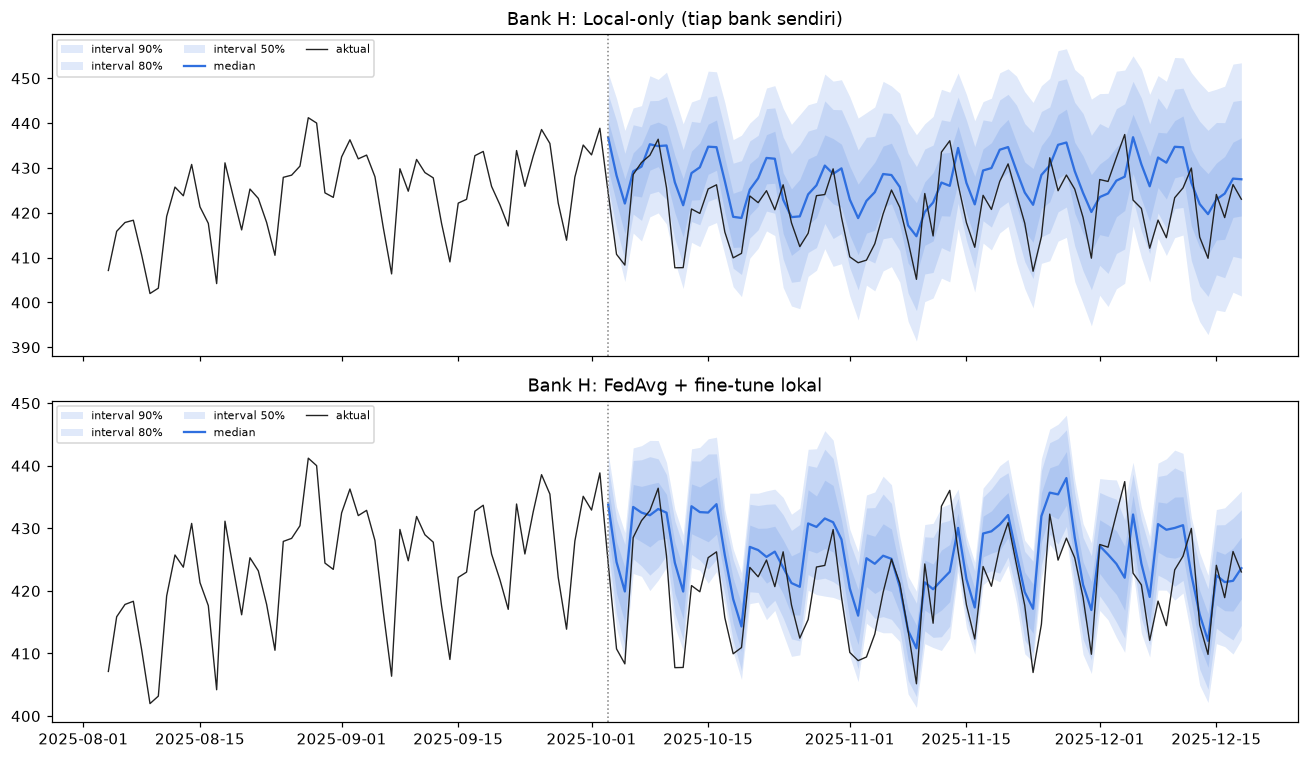

In [6]:
r = results["data_langka"]; k = 7; c = r.clients[k]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, meth in zip(axes, ["local", "fedavg_ft"]):
    plot_fan(r.sim, k, r.pred_original_scale(meth, k), c.test.origins, ax=ax, title=f"{c.name}: {METHOD_LABELS[meth]}")
plt.tight_layout()

## Skenario shock: apakah model tetap jujur saat terjadi guncangan?

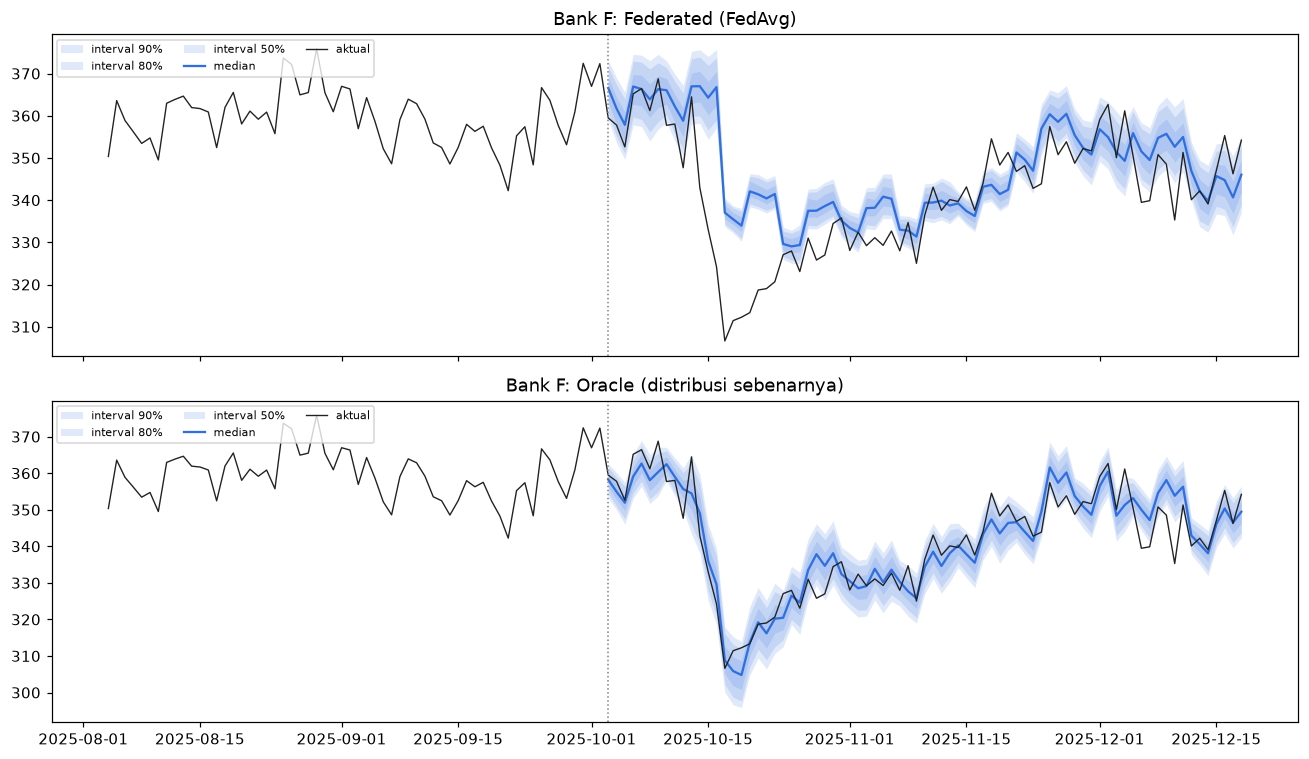

In [7]:
r = results["shock"]; k = 5; c = r.clients[k]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, meth in zip(axes, ["fedavg", "oracle"]):
    plot_fan(r.sim, k, r.pred_original_scale(meth, k), c.test.origins, ax=ax, title=f"{c.name}: {METHOD_LABELS[meth]}")
plt.tight_layout()

## Apakah hasilnya stabil? Ulangi `data_langka` dengan beberapa seed
Satu periode uji itu berisik (lihat catatan Oracle di notebook 02). Karena itu kita ulangi
simulasi dengan seed berbeda, lalu fokus pada bank kecil yang datanya langka.

In [8]:
SEEDS = [42, 7, 123]
FOCUS = ["oracle", "local", "fedavg", "fedavg_ft", "central"]
rows = []
for sd in SEEDS:
    r = run_experiment_cached(get_scenario("data_langka", seed=sd), methods=tuple(FOCUS), cache_dir="../results", verbose=False)
    mm = r.metrics.copy(); mm["seed"] = sd
    rows.append(mm)
seeds_df = pd.concat(rows)
seeds_df["kelompok"] = np.where(seeds_df["bank"].isin(["Bank F", "Bank G", "Bank H"]), "bank kecil (data langka)", "bank lain")
seeds_df.groupby(["kelompok", "method"])[["CRPS", "Coverage80"]].agg(["mean", "std"]).loc[:, :].round(3)

CRPS        Coverage80       
                                     mean    std       mean    std
kelompok                 method                                   
bank kecil (data langka) central    0.154  0.020      0.840  0.087
                         fedavg     0.156  0.021      0.837  0.082
                         fedavg_ft  0.154  0.019      0.832  0.082
                         local      0.215  0.020      0.961  0.027
                         oracle     0.122  0.018      0.798  0.063
bank lain                central    0.173  0.031      0.781  0.097
                         fedavg     0.172  0.030      0.779  0.088
                         fedavg_ft  0.171  0.030      0.770  0.090
                         local      0.178  0.032      0.753  0.099
                         oracle     0.152  0.027      0.774  0.074

Text(0.5, 1.0, 'Siapa yang paling diuntungkan federated learning?')

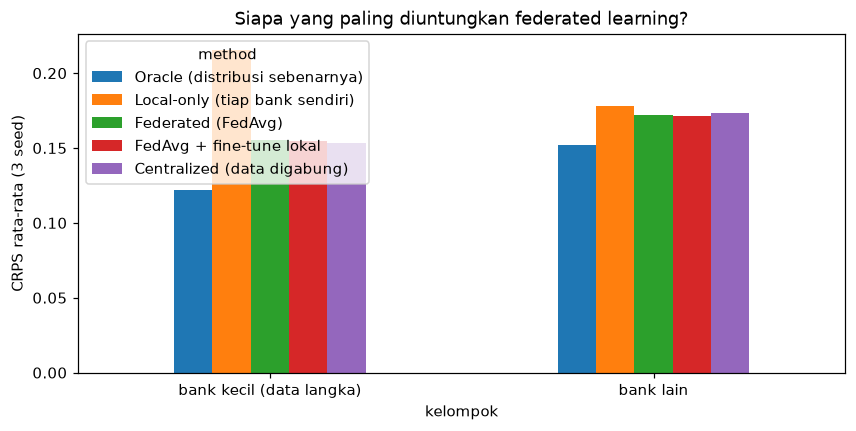

In [9]:
pivot = seeds_df.groupby(["kelompok", "method"])["CRPS"].mean().unstack()[FOCUS]
ax = pivot.rename(columns=METHOD_LABELS).plot.bar(figsize=(9, 4), rot=0)
ax.set_ylabel("CRPS rata-rata (3 seed)"); ax.set_title("Siapa yang paling diuntungkan federated learning?")

## Sweep heterogenitas (alpha)

method,local,fedavg,fedprox,fedavg_ft,central
0.0,0.192,0.197,0.190,0.200,0.184
0.3,0.195,0.203,0.198,0.201,0.199
0.6,0.193,0.209,0.207,0.199,0.216
0.9,0.201,0.223,0.223,0.205,0.212


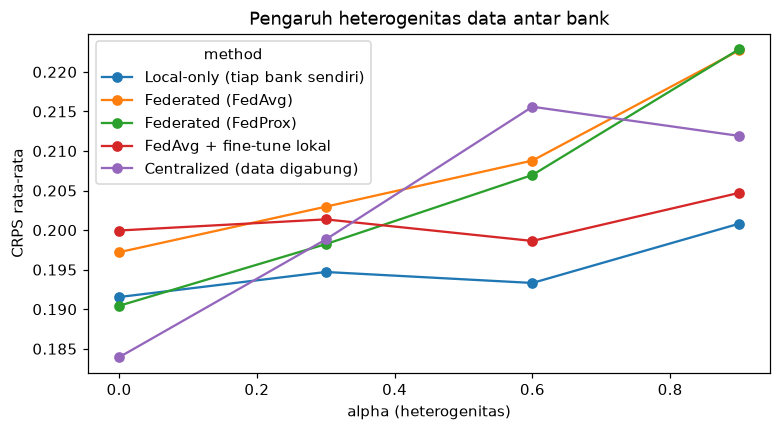

In [10]:
alphas = [0.0, 0.3, 0.6, 0.9]
sweep = []
for a in alphas:
    r = run_experiment_cached(get_scenario("normal", alpha=a), methods=("local", "fedavg", "fedprox", "fedavg_ft", "central"),
                              cache_dir="../results", verbose=False)
    sweep.append(r.summary()["CRPS"].rename(a))
sweep = pd.DataFrame(sweep)
ax = sweep.rename(columns=METHOD_LABELS).plot(marker="o", figsize=(8, 4))
ax.set_xlabel("alpha (heterogenitas)"); ax.set_ylabel("CRPS rata-rata"); ax.set_title("Pengaruh heterogenitas data antar bank")
sweep

## Kesimpulan sementara
*(Berdasarkan eksekusi 2026-10-08; angka pasti lihat tabel di atas dan `PROGRESS.md`.)*

1. **Federated learning paling menolong bank dengan data sedikit.** Pada `data_langka` (rata-rata 3 seed),
   CRPS bank kecil turun dari ~0.215 (Local) ke ~0.156 (FedAvg), **sekitar 27% lebih baik**, dan setara
   Centralized (~0.154) **tanpa satu pun data dibagikan**. Interval model lokal terlalu lebar (coverage 96%);
   federasi membuatnya lebih tajam dan tetap terkalibrasi (~84%).
2. **Bank dengan data banyak hampir tidak diuntungkan.** Pada skenario `normal`, Local ≈ FedAvg ≈ Centralized.
   Data yang cukup sudah memadai untuk proses sesederhana ini.
3. **Heterogenitas (non-IID) melemahkan FedAvg.** Saat alpha naik, CRPS FedAvg memburuk, dan
   **personalisasi (fine-tune lokal)** memulihkan sebagian besar kerugian. FedProx belum memberi
   perbaikan berarti di sini.
4. **Semua model gagal saat shock.** Coverage 80% anjlok ke ~40%: model yang belajar dari data
   "normal" menjadi **terlalu percaya diri** ketika dunia berubah. Ini menjawab langsung pertanyaan
   riset tentang model yang *jujur soal ketidakpastian* dan menjadi motivasi tahap berikutnya.

## Langkah riset berikutnya
1. **Diffusion model** untuk membangkitkan skenario masa depan (arah riset ke-2 di essay).
2. Model global yang lebih kuat (Transformer/TFT, DeepAR) dan forecast konformal untuk menjamin coverage.
3. Privasi formal: *differential privacy* dan *secure aggregation* pada FedAvg.
4. Validasi pada data riil publik, misalnya data perbankan agregat per provinsi.